# Analysis of Block-Bootstrapped Return Paths

This notebook analyzes the block-bootstrapped return paths generated in `2__block_boostrap.ipynb`. We examine:

1. **Mean returns and volatilities** across asset classes
2. **Correlation structure** at different time horizons (1, 5, 10, 40 years)
3. **Variance ratios** - how variance scales with horizon
4. **Long-horizon properties** that distinguish bonds from equities

Key insight from Anarkulova et al. (2025): Bonds appear to diversify at short horizons but fail at long horizons due to:
- Increasing variance ratios (persistence)
- Rising correlation with stocks
- Strong negative correlation with inflation

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Paths
DATA_DIR = Path("./Final")
PATHS_FILE = DATA_DIR / "block_bootstrapped_paths.npy"
ORDER_FILE = DATA_DIR / "asset_class_order.txt"

## Load Data

In [64]:
# Load asset class order
with open(ORDER_FILE, 'r') as f:
    asset_classes = [line.strip() for line in f]

print(f"Asset classes: {asset_classes}")

# Load bootstrapped paths
# Shape: (n_paths, T, n_assets)
paths = np.load(PATHS_FILE)
n_paths, T, n_assets = paths.shape

print(f"\nLoaded {n_paths:,} paths of {T} years each")
print(f"Asset classes: {n_assets}")
print(f"Array shape: {paths.shape}")

Asset classes: ['Equities', 'Bonds', 'Bills', 'CPI']

Loaded 464,994 paths of 40 years each
Asset classes: 4
Array shape: (464994, 40, 4)


## 1. Summary Statistics: Single-Period Returns

First, let's look at the basic properties of annual returns.

In [65]:
# Flatten all years across all paths for single-period analysis
# Shape: (n_paths * T, n_assets)
all_returns = paths.reshape(-1, n_assets)

# Create summary statistics
summary_stats = pd.DataFrame({
    'Mean': all_returns.mean(axis=0) * 100,
    'Std Dev': all_returns.std(axis=0) * 100,
    'Median': np.median(all_returns, axis=0) * 100,
    'Skewness': pd.DataFrame(all_returns).skew().values,
    'Kurtosis': pd.DataFrame(all_returns).kurtosis().values,
    'Min': all_returns.min(axis=0) * 100,
    'Max': all_returns.max(axis=0) * 100
}, index=asset_classes)

# Calculate Sharpe ratios (assuming Bills as risk-free rate)
bills_idx = asset_classes.index('Bills')
excess_returns = all_returns - all_returns[:, bills_idx:bills_idx+1]
summary_stats['Sharpe'] = (excess_returns.mean(axis=0) / all_returns.std(axis=0))
summary_stats.loc['Bills', 'Sharpe'] = 0  # By definition

print("\n" + "="*80)
print("SINGLE-PERIOD (ANNUAL) RETURN STATISTICS")
print("="*80)
print(summary_stats.round(2))


SINGLE-PERIOD (ANNUAL) RETURN STATISTICS
           Mean  Std Dev  Median  Skewness  Kurtosis    Min      Max  Sharpe
Equities  12.31    36.89   10.86     27.11    940.43 -43.33  1344.58    0.21
Bonds      5.57     6.15    4.50      0.98      1.49  -9.11    34.79    0.17
Bills      4.53     3.32    4.00      1.56      3.36  -2.00    21.27    0.00
CPI        5.66    35.98    2.35     24.25    650.68 -23.50  1023.71    0.03


## 2. Correlation Matrix: Single Period

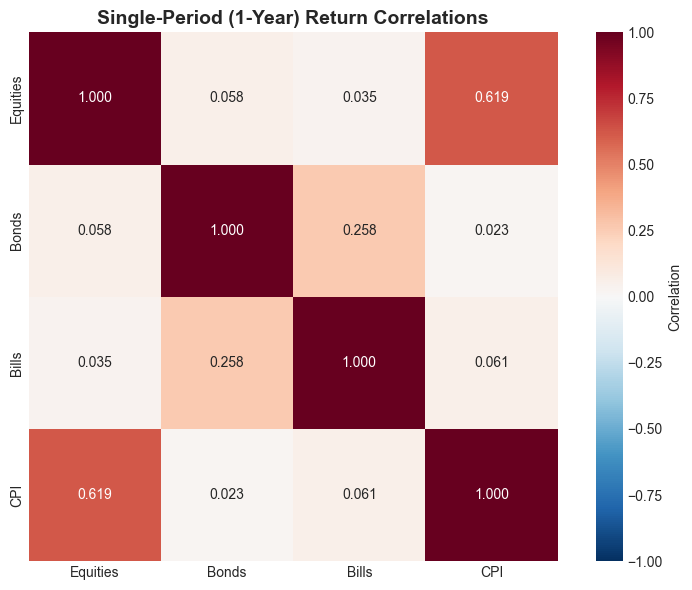


Key Correlations (1-year):
  Equities-Bonds: 0.058
  Equities-CPI: 0.619
  Bonds-CPI: 0.023
  Bills-CPI: 0.061


In [66]:
# Single-period correlation matrix
corr_1yr = pd.DataFrame(all_returns, columns=asset_classes).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_1yr, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'label': 'Correlation'})
ax.set_title('Single-Period (1-Year) Return Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Correlations (1-year):")
print(f"  Equities-Bonds: {corr_1yr.loc['Equities', 'Bonds']:.3f}")
print(f"  Equities-CPI: {corr_1yr.loc['Equities', 'CPI']:.3f}")
print(f"  Bonds-CPI: {corr_1yr.loc['Bonds', 'CPI']:.3f}")
print(f"  Bills-CPI: {corr_1yr.loc['Bills', 'CPI']:.3f}")

## 3. Multi-Horizon Analysis

Now we examine how returns, volatilities, and correlations change at different holding periods.

### 3.1 Compute Cumulative Returns at Different Horizons

In [67]:
def compute_horizon_returns(paths, horizon):
    """
    Compute overlapping horizon returns.
    
    For a horizon of H years, return from year t to t+H is:
    R(t, H) = (1 + r_t) * (1 + r_{t+1}) * ... * (1 + r_{t+H-1}) - 1
    
    Returns: array of shape (n_valid_periods, n_assets)
    where n_valid_periods = (T - horizon + 1) * n_paths
    """
    n_paths, T, n_assets = paths.shape
    
    if horizon > T:
        raise ValueError(f"Horizon {horizon} exceeds path length {T}")
    
    horizon_returns = []
    
    for path in paths:
        for start_idx in range(T - horizon + 1):
            # Cumulative return: product of (1 + r) - 1
            period_returns = path[start_idx:start_idx + horizon]
            cum_return = np.prod(1 + period_returns, axis=0) - 1
            horizon_returns.append(cum_return)
    
    return np.array(horizon_returns)

# Compute for different horizons
horizons = [1, 5, 10, 20, 40]
horizon_data = {}

print("Computing multi-horizon returns...")
for h in horizons:
    if h <= T:
        print(f"  {h}-year horizon...")
        horizon_data[h] = compute_horizon_returns(paths, h)
        n_obs = len(horizon_data[h])
        print(f"    Generated {n_obs:,} overlapping {h}-year periods")
    else:
        print(f"  Skipping {h}-year horizon (exceeds path length {T})")

print("\nDone!")

Computing multi-horizon returns...
  1-year horizon...
    Generated 18,599,760 overlapping 1-year periods
  5-year horizon...
    Generated 16,739,784 overlapping 5-year periods
  10-year horizon...
    Generated 14,414,814 overlapping 10-year periods
  20-year horizon...
    Generated 9,764,874 overlapping 20-year periods
  40-year horizon...
    Generated 464,994 overlapping 40-year periods

Done!


### 3.2 Annualized Returns and Volatilities by Horizon

In [68]:
# Annualized statistics
annualized_stats = {}

for h, returns in horizon_data.items():
    # Annualize cumulative returns: (1 + R_H)^(1/H) - 1
    annualized_returns = (1 + returns) ** (1/h) - 1
    
    annualized_stats[h] = pd.DataFrame({
        'Mean': annualized_returns.mean(axis=0) * 100,
        'Std Dev': annualized_returns.std(axis=0) * 100,
    }, index=asset_classes)

# Display as multi-index DataFrame
combined = pd.concat(annualized_stats, names=['Horizon', 'Asset'])

print("\n" + "="*80)
print("ANNUALIZED RETURNS AND VOLATILITIES BY HORIZON")
print("="*80)
print(combined.round(2))


ANNUALIZED RETURNS AND VOLATILITIES BY HORIZON
                   Mean  Std Dev
Horizon Asset                   
1       Equities  12.31    36.89
        Bonds      5.57     6.15
        Bills      4.53     3.32
        CPI        5.66    35.98
5       Equities  10.83     9.78
        Bonds      5.44     3.08
        Bills      4.52     2.86
        CPI        4.63     9.47
10      Equities  10.65     6.64
        Bonds      5.43     2.44
        Bills      4.51     2.47
        CPI        4.49     6.72
20      Equities  10.56     4.61
        Bonds      5.42     1.85
        Bills      4.50     1.93
        CPI        4.40     4.73
40      Equities  10.50     3.22
        Bonds      5.41     1.35
        Bills      4.49     1.42
        CPI        4.35     3.31


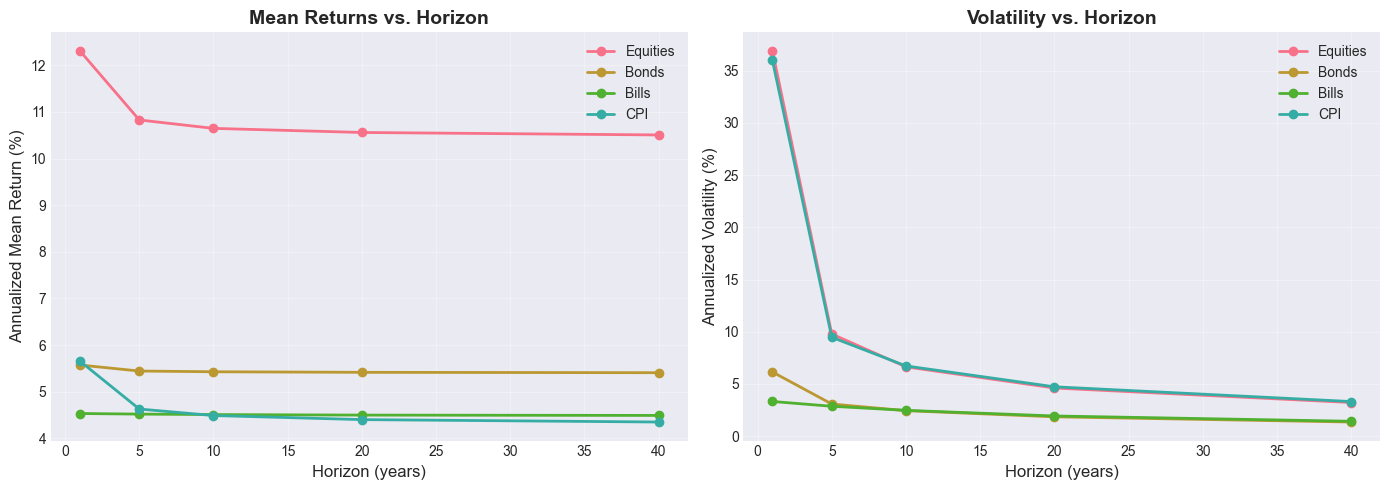

In [69]:
# Visualize how volatility changes with horizon
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean returns
for asset in asset_classes:
    means = [annualized_stats[h].loc[asset, 'Mean'] for h in horizon_data.keys()]
    axes[0].plot(list(horizon_data.keys()), means, marker='o', label=asset, linewidth=2)

axes[0].set_xlabel('Horizon (years)', fontsize=12)
axes[0].set_ylabel('Annualized Mean Return (%)', fontsize=12)
axes[0].set_title('Mean Returns vs. Horizon', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Volatility
for asset in asset_classes:
    vols = [annualized_stats[h].loc[asset, 'Std Dev'] for h in horizon_data.keys()]
    axes[1].plot(list(horizon_data.keys()), vols, marker='o', label=asset, linewidth=2)

axes[1].set_xlabel('Horizon (years)', fontsize=12)
axes[1].set_ylabel('Annualized Volatility (%)', fontsize=12)
axes[1].set_title('Volatility vs. Horizon', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Variance Ratios

The **variance ratio** measures how variance scales with horizon. For IID returns:
$$\text{VR}(H) = \frac{\text{Var}(R_H)}{H \times \text{Var}(R_1)} = 1$$

- VR < 1: Mean reversion (variance grows slower than linearly)
- VR > 1: Momentum/persistence (variance grows faster than linearly)

Anarkulova et al. find bonds have VR ≈ 2.3 and equities VR ≈ 0.75 at 30-year horizons.

**Note:** For proper variance ratio analysis, we should use **log returns** (which sum) rather than 
simple returns (which compound). This gives cleaner interpretation since IID log returns have VR=1.

In [70]:
# Compute variance ratios using LOG returns for proper interpretation
# Traditional formula: VR(H) = Var(H-period log return) / (H × Var(1-period log return))
# For IID returns, VR = 1. VR < 1 means mean reversion, VR > 1 means persistence.

# Convert to log returns: log(1 + r)
log_returns_1yr = np.log(1 + all_returns)
var_1yr_log = log_returns_1yr.var(axis=0)

variance_ratios = {}
for h, returns in horizon_data.items():
    # Convert cumulative simple returns to log returns: log(1 + R_H)
    # For cumulative return R_H = (1+r1)×...×(1+rH)-1, we have log(1+R_H) = sum of log(1+ri)
    log_returns_h = np.log(1 + returns)
    var_h_log = log_returns_h.var(axis=0)
    variance_ratios[h] = var_h_log / (h * var_1yr_log)

vr_df = pd.DataFrame(variance_ratios, index=asset_classes).T
vr_df.index.name = 'Horizon'

print("\n" + "="*80)
print("VARIANCE RATIOS BY HORIZON")
print("="*80)
print("VR < 1: Mean reversion (variance grows slower than horizon)")
print("VR = 1: IID returns (variance grows linearly with horizon)")
print("VR > 1: Momentum/persistence (variance grows faster than horizon)")
print("="*80)
print(vr_df.round(3))


VARIANCE RATIOS BY HORIZON
VR < 1: Mean reversion (variance grows slower than horizon)
VR = 1: IID returns (variance grows linearly with horizon)
VR > 1: Momentum/persistence (variance grows faster than horizon)
         Equities  Bonds  Bills    CPI
Horizon                               
1           1.000  1.000  1.000  1.000
5           1.223  1.284  3.749  1.964
10          1.253  1.628  5.636  2.374
20          1.290  1.889  6.971  2.598
40          1.301  2.023  7.646  2.694


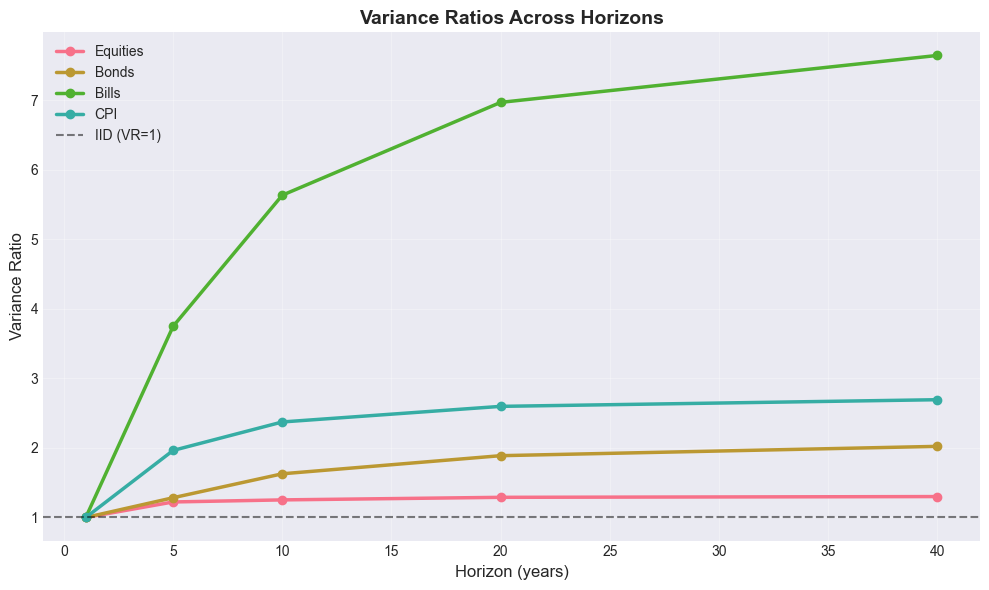


Interpretation:
- VR = 1: Returns are IID (independent and identically distributed)
- VR < 1: Mean reversion (equities tend to show this - safer at long horizons)
- VR > 1: Persistence/momentum (bonds tend to show this - riskier at long horizons)

Anarkulova et al. (2025) find at 30-year horizon:
  - Bonds VR ≈ 2.3 (variance grows faster than horizon)
  - Equities VR ≈ 0.75 (variance grows slower than horizon)


In [71]:
# Plot variance ratios
fig, ax = plt.subplots(figsize=(10, 6))

for asset in asset_classes:
    ax.plot(vr_df.index, vr_df[asset], marker='o', label=asset, linewidth=2.5)

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='IID (VR=1)')
ax.set_xlabel('Horizon (years)', fontsize=12)
ax.set_ylabel('Variance Ratio', fontsize=12)
ax.set_title('Variance Ratios Across Horizons', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- VR = 1: Returns are IID (independent and identically distributed)")
print("- VR < 1: Mean reversion (equities tend to show this - safer at long horizons)")
print("- VR > 1: Persistence/momentum (bonds tend to show this - riskier at long horizons)")
print("\nAnarkulova et al. (2025) find at 30-year horizon:")
print("  - Bonds VR ≈ 2.3 (variance grows faster than horizon)")
print("  - Equities VR ≈ 0.75 (variance grows slower than horizon)")

## 4. Multi-Horizon Correlation Matrices

Key question: How does correlation structure change with investment horizon?

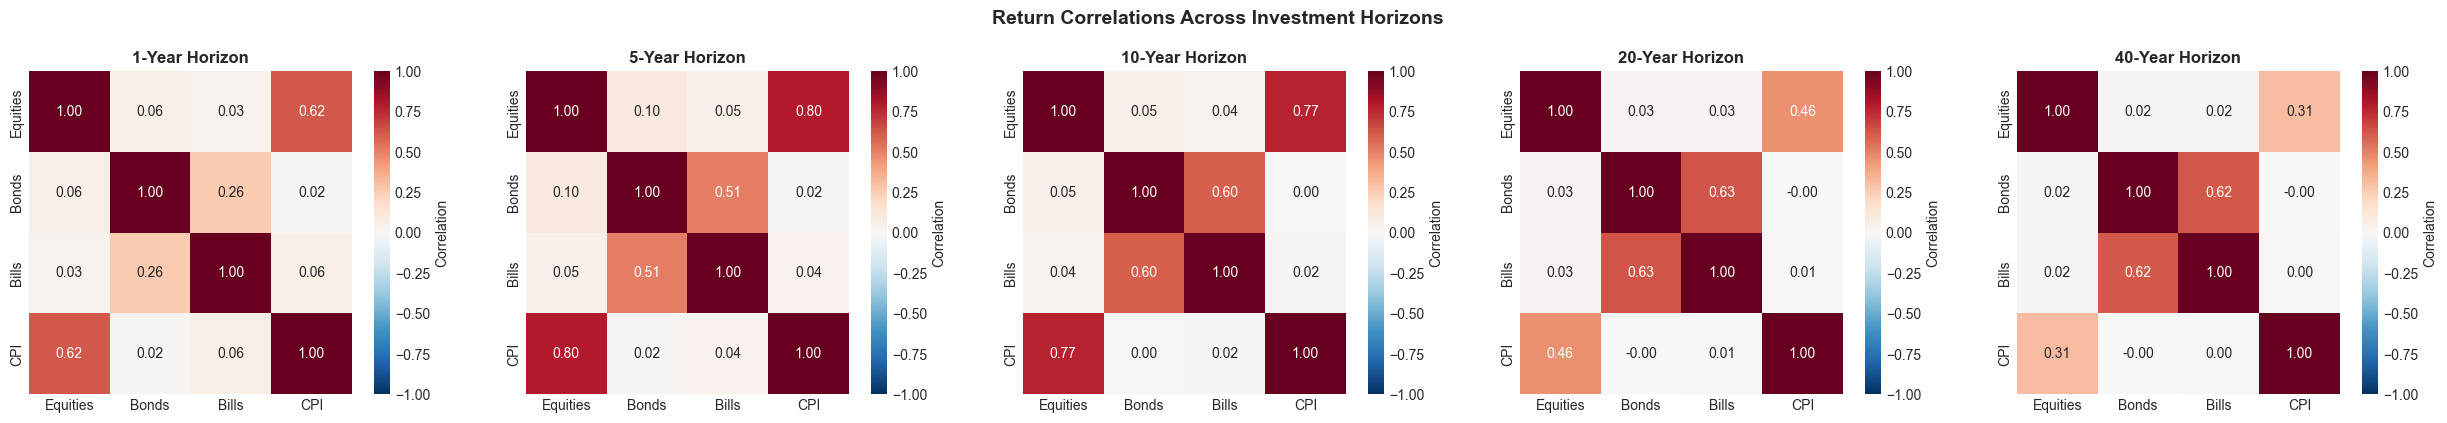

In [72]:
# Compute correlation matrices for each horizon
correlations = {}
for h, returns in horizon_data.items():
    correlations[h] = pd.DataFrame(returns, columns=asset_classes).corr()

# Plot correlation heatmaps
n_horizons = len(correlations)
fig, axes = plt.subplots(1, n_horizons, figsize=(5*n_horizons, 4))

if n_horizons == 1:
    axes = [axes]

for (h, corr_matrix), ax in zip(correlations.items(), axes):
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, ax=ax,
                cbar_kws={'label': 'Correlation'})
    ax.set_title(f'{h}-Year Horizon', fontsize=12, fontweight='bold')

plt.suptitle('Return Correlations Across Investment Horizons', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.1 Track Key Correlations Across Horizons

In [73]:
# Extract key correlation pairs
key_pairs = [
    ('Equities', 'Bonds'),
    ('Equities', 'CPI'),
    ('Bonds', 'CPI'),
    ('Bills', 'CPI'),
    ('Equities', 'Bills'),
    ('Bonds', 'Bills')
]

correlation_evolution = pd.DataFrame(
    {h: [correlations[h].loc[a1, a2] for a1, a2 in key_pairs] 
     for h in horizon_data.keys()},
    index=[f"{a1}-{a2}" for a1, a2 in key_pairs]
).T
correlation_evolution.index.name = 'Horizon'

print("\n" + "="*80)
print("CORRELATION EVOLUTION ACROSS HORIZONS")
print("="*80)
print(correlation_evolution.round(3))


CORRELATION EVOLUTION ACROSS HORIZONS
         Equities-Bonds  Equities-CPI  Bonds-CPI  Bills-CPI  Equities-Bills  \
Horizon                                                                       
1                 0.058         0.619      0.023      0.061           0.035   
5                 0.095         0.796      0.019      0.045           0.052   
10                0.047         0.771      0.003      0.022           0.035   
20                0.030         0.460     -0.001      0.005           0.027   
40                0.021         0.312     -0.001      0.003           0.021   

         Bonds-Bills  
Horizon               
1              0.258  
5              0.512  
10             0.600  
20             0.629  
40             0.623  


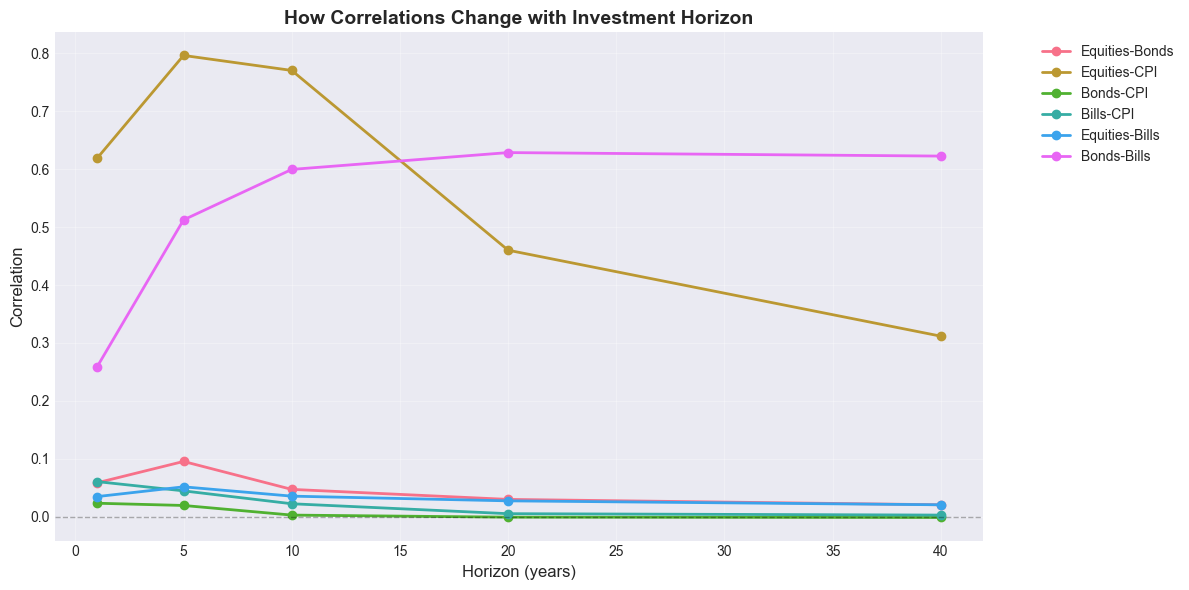


Key Insights:
- Bonds-CPI correlation at 1yr: 0.023
- Bonds-CPI correlation at 40yr: -0.001
- Equities-CPI correlation at 40yr: 0.312

→ Bonds become WORSE inflation hedge at long horizons!


In [74]:
# Plot correlation evolution
fig, ax = plt.subplots(figsize=(12, 6))

for pair in correlation_evolution.columns:
    ax.plot(correlation_evolution.index, correlation_evolution[pair], 
            marker='o', label=pair, linewidth=2)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.3)
ax.set_xlabel('Horizon (years)', fontsize=12)
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title('How Correlations Change with Investment Horizon', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"- Bonds-CPI correlation at 1yr: {correlations[1].loc['Bonds', 'CPI']:.3f}")
if 40 in correlations:
    print(f"- Bonds-CPI correlation at 40yr: {correlations[40].loc['Bonds', 'CPI']:.3f}")
    print(f"- Equities-CPI correlation at 40yr: {correlations[40].loc['Equities', 'CPI']:.3f}")
    print(f"\n→ Bonds become WORSE inflation hedge at long horizons!")

## 5. Real Returns Analysis

Since inflation correlation matters for purchasing power, let's examine real (inflation-adjusted) returns.

In [75]:
# Compute real returns at different horizons
cpi_idx = asset_classes.index('CPI')

real_return_stats = {}

for h, returns in horizon_data.items():
    # Real return: (1 + nominal) / (1 + inflation) - 1
    real_returns = (1 + returns) / (1 + returns[:, cpi_idx:cpi_idx+1]) - 1
    
    # Annualize
    annualized_real = (1 + real_returns) ** (1/h) - 1
    
    real_return_stats[h] = pd.DataFrame({
        'Mean': annualized_real.mean(axis=0) * 100,
        'Std Dev': annualized_real.std(axis=0) * 100,
    }, index=asset_classes)

# Display
real_combined = pd.concat(real_return_stats, names=['Horizon', 'Asset'])

print("\n" + "="*80)
print("REAL (INFLATION-ADJUSTED) ANNUALIZED RETURNS BY HORIZON")
print("="*80)
print(real_combined.round(2))


REAL (INFLATION-ADJUSTED) ANNUALIZED RETURNS BY HORIZON
                  Mean  Std Dev
Horizon Asset                  
1       Equities  7.27    18.35
        Bonds     1.73    10.11
        Bills     0.67     7.85
        CPI       0.00     0.00
5       Equities  6.19     7.69
        Bonds     1.35     7.15
        Bills     0.42     6.30
        CPI       0.00     0.00
10      Equities  6.04     5.30
        Bonds     1.24     5.83
        Bills     0.32     5.16
        CPI       0.00     0.00
20      Equities  5.97     3.70
        Bonds     1.16     4.46
        Bills     0.25     3.96
        CPI       0.00     0.00
40      Equities  5.94     2.59
        Bonds     1.11     3.28
        Bills     0.22     2.91
        CPI       0.00     0.00


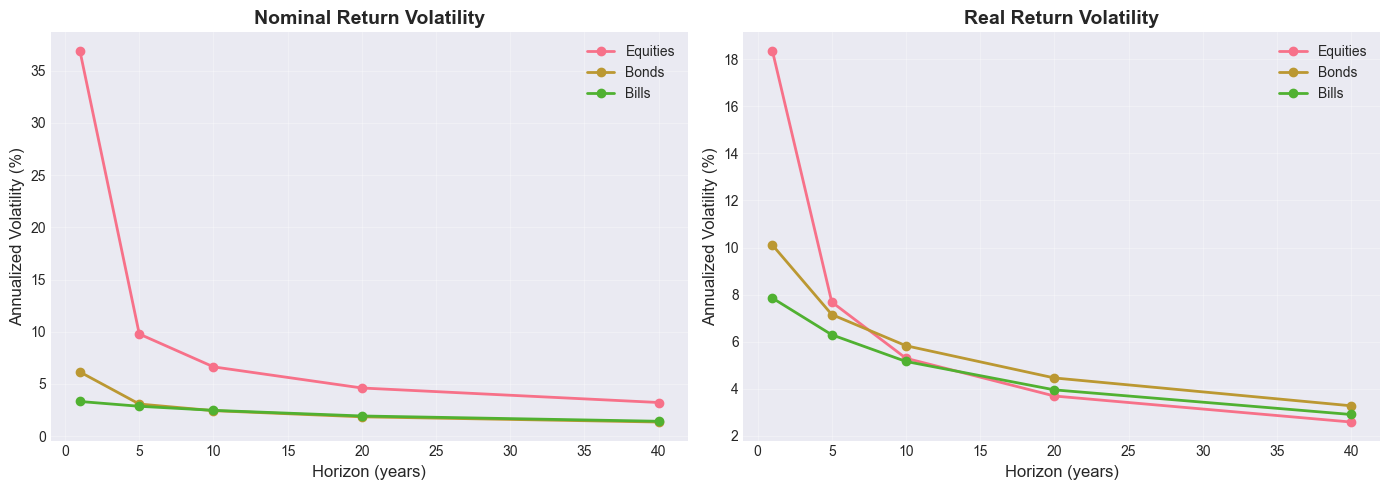


Note: Real volatility can be higher than nominal if inflation is volatile
and negatively correlated with the asset (inflation risk).


In [76]:
# Compare nominal vs real volatility
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nominal volatility
for asset in [a for a in asset_classes if a != 'CPI']:
    vols = [annualized_stats[h].loc[asset, 'Std Dev'] for h in horizon_data.keys()]
    axes[0].plot(list(horizon_data.keys()), vols, marker='o', label=asset, linewidth=2)

axes[0].set_xlabel('Horizon (years)', fontsize=12)
axes[0].set_ylabel('Annualized Volatility (%)', fontsize=12)
axes[0].set_title('Nominal Return Volatility', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Real volatility
for asset in [a for a in asset_classes if a != 'CPI']:
    vols = [real_return_stats[h].loc[asset, 'Std Dev'] for h in horizon_data.keys()]
    axes[1].plot(list(horizon_data.keys()), vols, marker='o', label=asset, linewidth=2)

axes[1].set_xlabel('Horizon (years)', fontsize=12)
axes[1].set_ylabel('Annualized Volatility (%)', fontsize=12)
axes[1].set_title('Real Return Volatility', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: Real volatility can be higher than nominal if inflation is volatile")
print("and negatively correlated with the asset (inflation risk).")

## 6. Distribution Analysis

Let's visualize the full distribution of returns at different horizons.

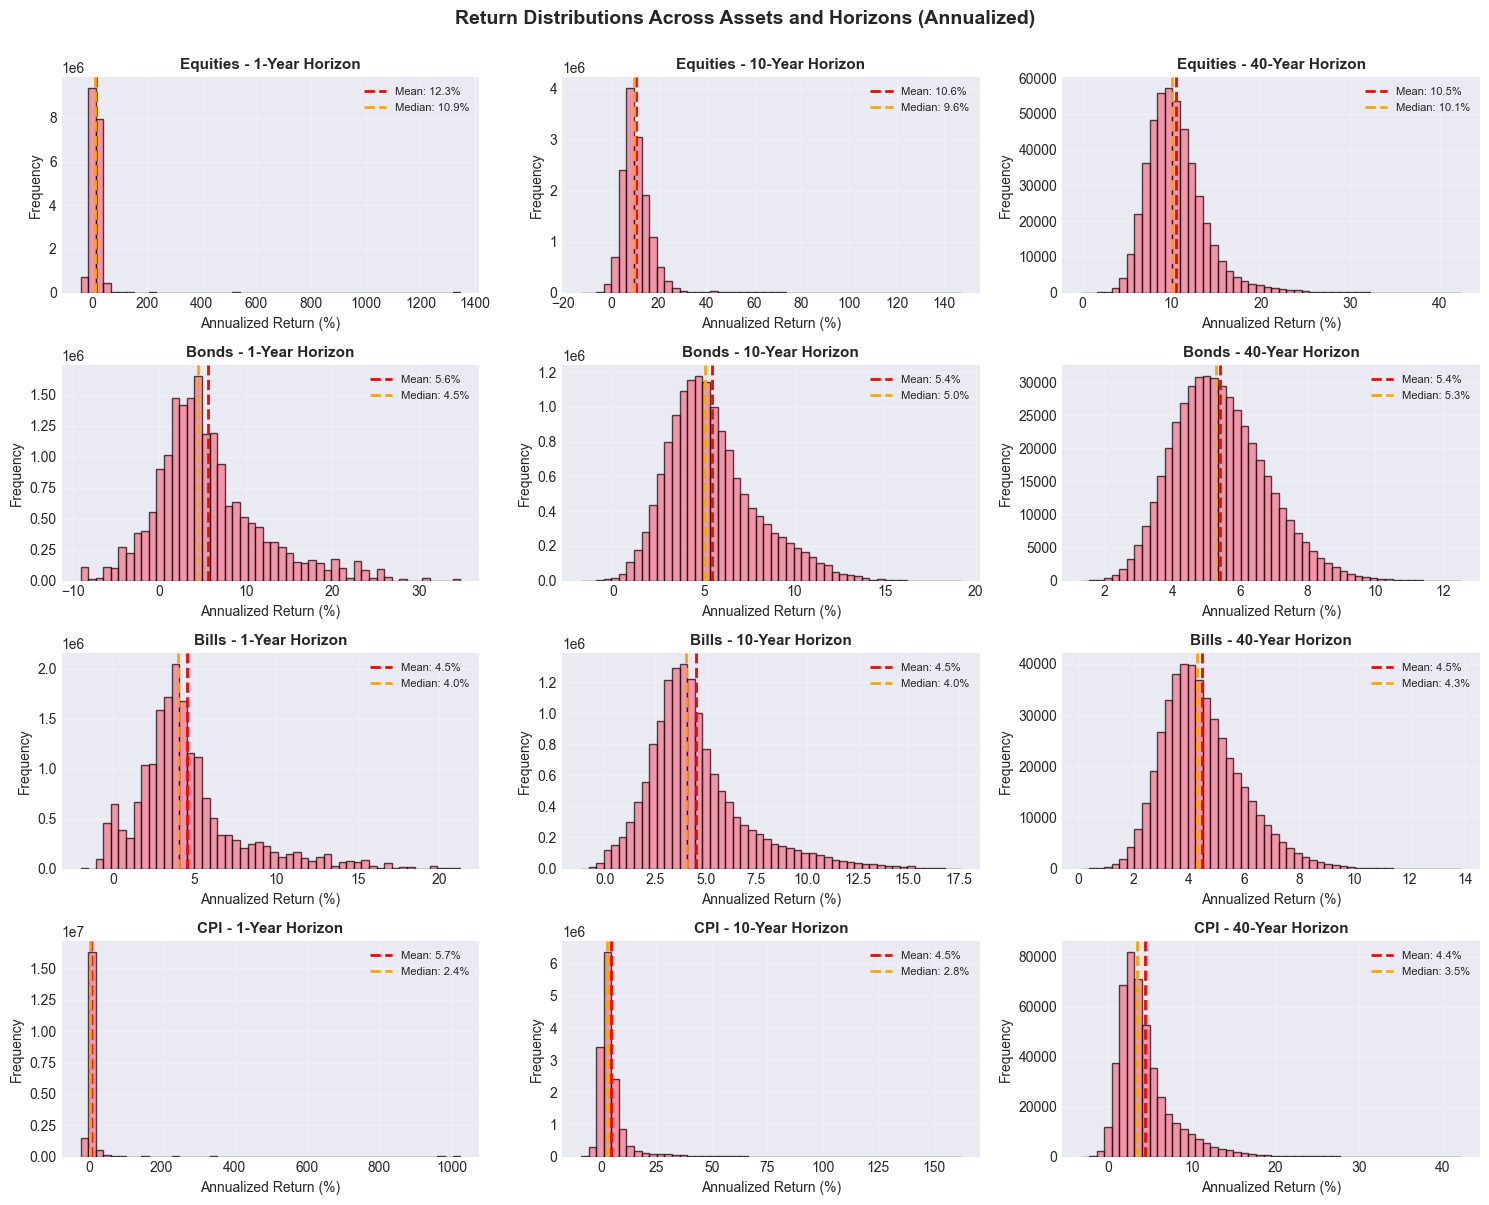

In [77]:
# Plot distributions for selected horizons
selected_horizons = [1, 10, 40] if 40 in horizon_data else [1, 10, 20]
n_selected = len(selected_horizons)

fig, axes = plt.subplots(n_assets, n_selected, figsize=(5*n_selected, 3*n_assets))

for i, asset in enumerate(asset_classes):
    for j, h in enumerate(selected_horizons):
        ax = axes[i, j] if n_assets > 1 else axes[j]
        
        # Get returns for this asset and horizon
        asset_returns = horizon_data[h][:, i]
        
        # Annualize for comparability
        annualized = (1 + asset_returns) ** (1/h) - 1
        
        # Plot histogram
        ax.hist(annualized * 100, bins=50, alpha=0.7, edgecolor='black')
        
        # Add vertical lines for mean and median
        mean_val = annualized.mean() * 100
        median_val = np.median(annualized) * 100
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}%')
        ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}%')
        
        ax.set_xlabel('Annualized Return (%)', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.set_title(f'{asset} - {h}-Year Horizon', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Return Distributions Across Assets and Horizons (Annualized)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 7. Sharpe Ratios Across Horizons

How does risk-adjusted performance change with horizon?

In [78]:
# Compute Sharpe ratios at each horizon
sharpe_ratios = {}

for h, returns in horizon_data.items():
    # Annualize
    annualized = (1 + returns) ** (1/h) - 1
    
    # Excess returns over bills
    excess = annualized - annualized[:, bills_idx:bills_idx+1]
    
    # Sharpe ratio
    sharpe = excess.mean(axis=0) / annualized.std(axis=0)
    sharpe[bills_idx] = 0  # Bills have zero Sharpe by definition
    
    sharpe_ratios[h] = sharpe

sharpe_df = pd.DataFrame(sharpe_ratios, index=asset_classes).T
sharpe_df.index.name = 'Horizon'

print("\n" + "="*80)
print("SHARPE RATIOS BY HORIZON")
print("="*80)
print(sharpe_df.round(3))


SHARPE RATIOS BY HORIZON
         Equities  Bonds  Bills    CPI
Horizon                               
1           0.211  0.169    0.0  0.031
5           0.645  0.300    0.0  0.012
10          0.925  0.376    0.0 -0.003
20          1.314  0.495    0.0 -0.020
40          1.866  0.678    0.0 -0.043


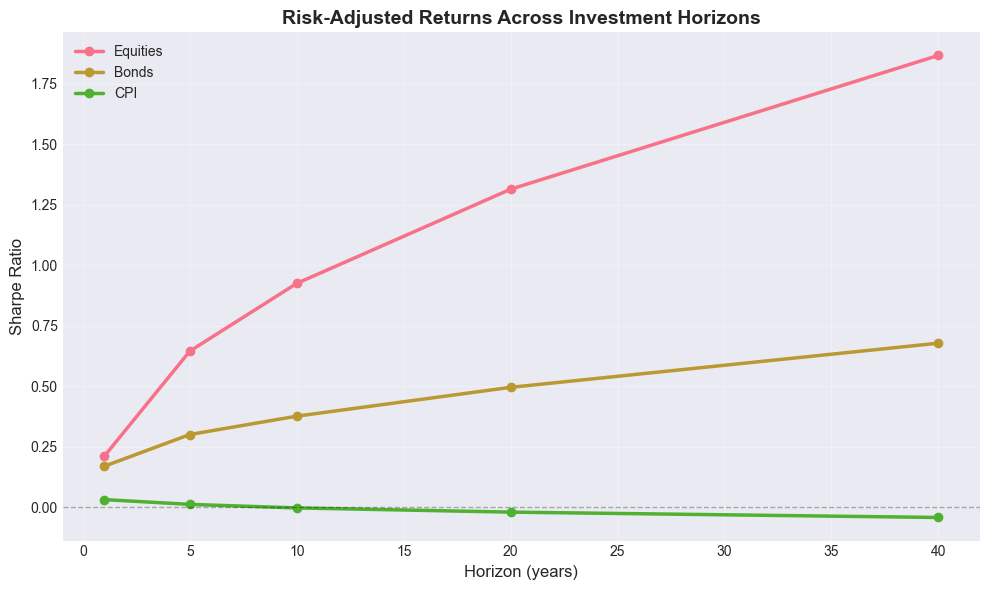


Interpretation:
- Higher Sharpe = better risk-adjusted returns
- If equities' Sharpe increases with horizon → long-horizon investors prefer equities
- If bonds' Sharpe decreases with horizon → bonds lose appeal for long-term


In [79]:
# Plot Sharpe ratio evolution
fig, ax = plt.subplots(figsize=(10, 6))

for asset in [a for a in asset_classes if a != 'Bills']:
    ax.plot(sharpe_df.index, sharpe_df[asset], marker='o', label=asset, linewidth=2.5)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.3)
ax.set_xlabel('Horizon (years)', fontsize=12)
ax.set_ylabel('Sharpe Ratio', fontsize=12)
ax.set_title('Risk-Adjusted Returns Across Investment Horizons', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Higher Sharpe = better risk-adjusted returns")
print("- If equities' Sharpe increases with horizon → long-horizon investors prefer equities")
print("- If bonds' Sharpe decreases with horizon → bonds lose appeal for long-term")

## 8. Summary: Key Findings

Let's summarize the key differences between short and long horizons.

In [80]:
# Create comparison table for 1-year vs longest available horizon
longest_h = max(horizon_data.keys())

comparison = pd.DataFrame({
    '1-Year Mean (%)': annualized_stats[1]['Mean'],
    f'{longest_h}-Year Mean (%)': annualized_stats[longest_h]['Mean'],
    '1-Year Vol (%)': annualized_stats[1]['Std Dev'],
    f'{longest_h}-Year Vol (%)': annualized_stats[longest_h]['Std Dev'],
    '1-Year Sharpe': sharpe_df.loc[1],
    f'{longest_h}-Year Sharpe': sharpe_df.loc[longest_h],
    f'Variance Ratio ({longest_h}yr)': vr_df.loc[longest_h]
}, index=asset_classes)

print("\n" + "="*100)
print(f"SHORT HORIZON (1-YEAR) VS LONG HORIZON ({longest_h}-YEAR) COMPARISON")
print("="*100)
print(comparison.round(3))

print("\n" + "="*100)
print("KEY CORRELATIONS")
print("="*100)
print(f"\n1-Year Horizon:")
print(f"  Equities-Bonds: {correlations[1].loc['Equities', 'Bonds']:.3f}")
print(f"  Bonds-CPI: {correlations[1].loc['Bonds', 'CPI']:.3f}")
print(f"  Equities-CPI: {correlations[1].loc['Equities', 'CPI']:.3f}")

print(f"\n{longest_h}-Year Horizon:")
print(f"  Equities-Bonds: {correlations[longest_h].loc['Equities', 'Bonds']:.3f}")
print(f"  Bonds-CPI: {correlations[longest_h].loc['Bonds', 'CPI']:.3f}")
print(f"  Equities-CPI: {correlations[longest_h].loc['Equities', 'CPI']:.3f}")

print("\n" + "="*100)
print("CONCLUSION")
print("="*100)
bonds_vr = vr_df.loc[longest_h, 'Bonds']
eq_vr = vr_df.loc[longest_h, 'Equities']
print(f"\n→ Bonds show {'PERSISTENCE' if bonds_vr > 1.1 else 'near-IID behavior'} (VR={bonds_vr:.2f})")
print(f"→ Equities show {'MEAN REVERSION' if eq_vr < 0.9 else 'near-IID behavior'} (VR={eq_vr:.2f})")
print(f"→ Bonds-inflation correlation {'WORSENS' if correlations[longest_h].loc['Bonds', 'CPI'] < correlations[1].loc['Bonds', 'CPI'] else 'improves'} at long horizons")
print(f"→ This suggests equities are {'SAFER' if eq_vr < bonds_vr else 'RISKIER'} than bonds for long-term investors!")
print("\n" + "="*100)


SHORT HORIZON (1-YEAR) VS LONG HORIZON (40-YEAR) COMPARISON
          1-Year Mean (%)  40-Year Mean (%)  1-Year Vol (%)  40-Year Vol (%)  \
Equities           12.307            10.505          36.894            3.221   
Bonds               5.573             5.408           6.145            1.352   
Bills               4.534             4.492           3.320            1.425   
CPI                 5.657             4.351          35.982            3.314   

          1-Year Sharpe  40-Year Sharpe  Variance Ratio (40yr)  
Equities          0.211           1.866                  1.301  
Bonds             0.169           0.678                  2.023  
Bills             0.000           0.000                  7.646  
CPI               0.031          -0.043                  2.694  

KEY CORRELATIONS

1-Year Horizon:
  Equities-Bonds: 0.058
  Bonds-CPI: 0.023
  Equities-CPI: 0.619

40-Year Horizon:
  Equities-Bonds: 0.021
  Bonds-CPI: -0.001
  Equities-CPI: 0.312

CONCLUSION

→ Bonds show PER

## 9. Export Summary Statistics

Save key statistics for use in the paper.

In [81]:
# Create output directory if needed
output_dir = Path("./Analysis")
output_dir.mkdir(exist_ok=True)

# Save various summary tables
comparison.to_csv(output_dir / "horizon_comparison.csv")
vr_df.to_csv(output_dir / "variance_ratios.csv")
correlation_evolution.to_csv(output_dir / "correlation_evolution.csv")
sharpe_df.to_csv(output_dir / "sharpe_ratios_by_horizon.csv")

# Save correlation matrices
for h, corr_matrix in correlations.items():
    corr_matrix.to_csv(output_dir / f"correlation_matrix_{h}yr.csv")

print("\nSummary statistics saved to ./Analysis/")
print("\nFiles created:")
for f in output_dir.glob("*.csv"):
    print(f"  - {f.name}")


Summary statistics saved to ./Analysis/

Files created:
  - aggregate_variance_ratios_AUS.csv
  - aggregate_variance_ratios_DEU.csv
  - aggregate_variance_ratios_JPN.csv
  - aggregate_variance_ratios_NOR.csv
  - aggregate_variance_ratios_pooled.csv
  - aggregate_variance_ratios_SWE.csv
  - aggregate_variance_ratios_USA.csv
  - correlation_evolution.csv
  - correlation_matrix_10yr.csv
  - correlation_matrix_1yr.csv
  - correlation_matrix_20yr.csv
  - correlation_matrix_40yr.csv
  - correlation_matrix_5yr.csv
  - horizon_comparison.csv
  - sharpe_ratios_by_horizon.csv
  - subasset_variance_ratios_AUS.csv
  - subasset_variance_ratios_DEU.csv
  - subasset_variance_ratios_JPN.csv
  - subasset_variance_ratios_NOR.csv
  - subasset_variance_ratios_pooled.csv
  - subasset_variance_ratios_SWE.csv
  - subasset_variance_ratios_USA.csv
  - variance_ratios.csv
  - variance_ratios_cross_country_30yr.csv
